In [1]:
import json

file_path = r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\bounding_boxes.labels"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Number of pictures that are annotated:",
      len(data["boundingBoxes"]))

Number of pictures that are annotated: 563


In [33]:
import json

file_path = r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\bounding_boxes.labels"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

bounding_boxes = data["boundingBoxes"]

# Lưu tất cả label
labels = set()

for image_name, boxes in bounding_boxes.items():
    for box in boxes:
        labels.add(box["label"])

print("Labels in dataset:")

for label in sorted(labels):
    print("-", label)

Labels in dataset:
- mata_terbuka
- mata_terpejam
- menguap
- tidak_menguap


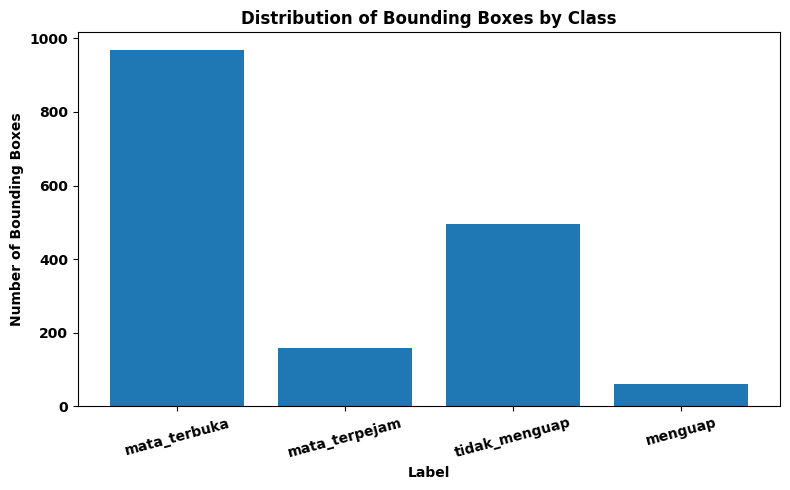

In [32]:
import matplotlib.pyplot as plt

labels = [
    "mata_terbuka",
    "mata_terpejam",
    "tidak_menguap",
    "menguap"
]

counts = [968, 158, 496, 60]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts)

plt.xlabel("Label")
plt.ylabel("Number of Bounding Boxes")
plt.title("Distribution of Bounding Boxes by Class")

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [36]:
import json
from pathlib import Path

# File annotation
annotation_file = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\bounding_boxes.labels"
)

# Thư mục chứa ảnh
image_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training"
)

# Đọc annotation
with open(annotation_file, "r", encoding="utf-8") as f:
    data = json.load(f)

annotations = data["boundingBoxes"]

# Lấy danh sách ảnh thật
image_files = {
    file.name
    for file in image_dir.iterdir()
    if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

annotated_files = set(annotations.keys())

missing_images = annotated_files - image_files
unannotated_images = image_files - annotated_files

print("Ảnh thật:", len(image_files))
print("Ảnh có annotation:", len(annotated_files))

print("\nẢnh có annotation nhưng không tìm thấy:")
print(len(missing_images))

print("\nẢnh có trong folder nhưng chưa có annotation:")
print(len(unannotated_images))

if missing_images:
    print("\nMột số ảnh bị thiếu:")
    for name in list(missing_images)[:10]:
        print(name)

if unannotated_images:
    print("\nMột số ảnh chưa annotation:")
    for name in list(unannotated_images)[:10]:
        print(name)

Ảnh thật: 563
Ảnh có annotation: 563

Ảnh có annotation nhưng không tìm thấy:
0

Ảnh có trong folder nhưng chưa có annotation:
0


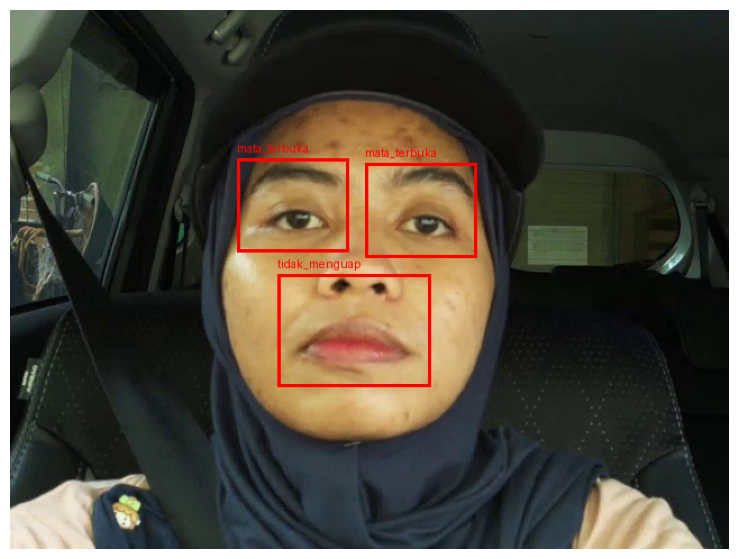

In [37]:
import json
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from pathlib import Path

annotation_file = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\bounding_boxes.labels"
)

image_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training"
)

with open(annotation_file, "r", encoding="utf-8") as f:
    data = json.load(f)

annotations = data["boundingBoxes"]

# Lấy ảnh đầu tiên
image_name = list(annotations.keys())[0]

image_path = image_dir / image_name

# Mở ảnh
image = Image.open(image_path).convert("RGB")

# Vẽ bounding box
draw = ImageDraw.Draw(image)

for box in annotations[image_name]:

    x = box["x"]
    y = box["y"]
    w = box["width"]
    h = box["height"]

    label = box["label"]

    draw.rectangle(
        [x, y, x + w, y + h],
        outline="red",
        width=3
    )

    draw.text(
        (x, y - 15),
        label,
        fill="red"
    )

# Hiển thị
plt.figure(figsize=(10, 7))
plt.imshow(image)
plt.axis("off")
plt.show()

In [38]:
from pathlib import Path

dataset_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training"
)

yolo_dir = dataset_dir / "yolo_dataset"

(yolo_dir / "images").mkdir(parents=True, exist_ok=True)
(yolo_dir / "labels").mkdir(parents=True, exist_ok=True)

In [39]:
from pathlib import Path
import shutil

dataset_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training"
)

yolo_images = dataset_dir / "yolo_dataset" / "images"

# Lấy tất cả ảnh
image_files = [
    f for f in dataset_dir.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

# Copy ảnh
for image_file in image_files:
    shutil.copy2(image_file, yolo_images / image_file.name)

print("Đã copy:", len(image_files), "ảnh")

Đã copy: 563 ảnh


In [40]:
import json
from pathlib import Path
from PIL import Image

# ==========================================
# ĐƯỜNG DẪN
# ==========================================

dataset_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training"
)

annotation_file = dataset_dir / "bounding_boxes.labels"

yolo_images = dataset_dir / "yolo_dataset" / "images"
yolo_labels = dataset_dir / "yolo_dataset" / "labels"


# ==========================================
# LABEL MAPPING
# ==========================================

label_map = {
    "mata_terbuka": 0,
    "mata_terpejam": 1,
    "tidak_menguap": 2,
    "menguap": 3
}


# ==========================================
# ĐỌC FILE ANNOTATION
# ==========================================

with open(annotation_file, "r", encoding="utf-8") as f:
    data = json.load(f)

annotations = data["boundingBoxes"]


# ==========================================
# CONVERT
# ==========================================

converted = 0
missing = 0

for image_name, boxes in annotations.items():

    image_path = yolo_images / image_name

    # Kiểm tra ảnh có tồn tại không
    if not image_path.exists():
        missing += 1
        continue

    # Lấy kích thước ảnh
    with Image.open(image_path) as img:
        image_width, image_height = img.size

    yolo_lines = []

    for box in boxes:

        label = box["label"]

        class_id = label_map[label]

        # Bounding box gốc
        x = box["x"]
        y = box["y"]
        width = box["width"]
        height = box["height"]

        # Chuyển sang tâm bounding box
        center_x = x + width / 2
        center_y = y + height / 2

        # Chuẩn hóa về 0 → 1
        center_x = center_x / image_width
        center_y = center_y / image_height
        width = width / image_width
        height = height / image_height

        # Format YOLO
        line = (
            f"{class_id} "
            f"{center_x:.6f} "
            f"{center_y:.6f} "
            f"{width:.6f} "
            f"{height:.6f}"
        )

        yolo_lines.append(line)

    # Tạo tên file txt
    label_file = yolo_labels / f"{Path(image_name).stem}.txt"

    # Ghi file
    with open(label_file, "w", encoding="utf-8") as f:
        f.write("\n".join(yolo_lines))

    converted += 1


# ==========================================
# KẾT QUẢ
# ==========================================

print("======================================")
print("CONVERT HOÀN TẤT")
print("======================================")

print("Ảnh có annotation :", len(annotations))
print("Đã convert        :", converted)
print("Không tìm thấy ảnh :", missing)

CONVERT HOÀN TẤT
Ảnh có annotation : 563
Đã convert        : 563
Không tìm thấy ảnh : 0


In [42]:
from pathlib import Path

labels_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\yolo_dataset\labels"
)

# Lấy file label đầu tiên
label_files = list(labels_dir.glob("*.txt"))

print("Số file label:", len(label_files))

# Đọc file đầu tiên
first_file = label_files[0]

print("\nFile đang kiểm tra:")
print(first_file.name)

print("\nNội dung:")
print(first_file.read_text(encoding="utf-8"))

Số file label: 563

File đang kiểm tra:
frame_0000_dhilah.jpg.jpg.5k32meth.ingestion-7489d9869d-t6pg4.txt

Nội dung:
0 0.369531 0.373958 0.151562 0.168750
0 0.539844 0.382292 0.151562 0.168750
2 0.452344 0.605208 0.198437 0.214583


In [43]:
from pathlib import Path

testing_dir = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\dts\testing"
)

files = list(testing_dir.iterdir())

print("Các file/folder trong testing:")
for f in files[:20]:
    print(f.name)

print("\nTổng số:", len(files))

Các file/folder trong testing:
bounding_boxes.labels
frame_0005_dhilah.jpg.jpg.5k32lctg.ingestion-7489d9869d-mrg62.jpg
frame_0010_uzan.jpg.jpg.5k32ktp3.ingestion-7489d9869d-mrg62.jpg
frame_0020_nugro.jpg.jpg.5k32l97u.ingestion-7489d9869d-25j9r.jpg
frame_0035_dhilah.jpg.jpg.5k32ld84.ingestion-7489d9869d-25j9r.jpg
frame_0050_nugro.jpg.jpg.5k32l9v3.ingestion-7489d9869d-t6pg4.jpg
frame_0065_uzan.jpg.jpg.5k32kuav.ingestion-7489d9869d-25j9r.jpg
frame_0075_nugro.jpg.jpg.5k32l9va.ingestion-7489d9869d-25j9r.jpg
frame_0105_nugro.jpg.jpg.5k32l9vh.ingestion-7489d9869d-mrg62.jpg
frame_0120_dhilah.jpg.jpg.5k32ldck.ingestion-7489d9869d-t6pg4.jpg
frame_0145_dhilah.jpg.jpg.5k32ldcm.ingestion-7489d9869d-25j9r.jpg
frame_0155_uzan.jpg.jpg.5k32l4mj.ingestion-7489d9869d-mrg62.jpg
frame_0170_nugro.jpg.jpg.5k32l9vn.ingestion-7489d9869d-t6pg4.jpg
frame_0185_dhilah.jpg.jpg.5k32ldcs.ingestion-7489d9869d-t6pg4.jpg
frame_0215_nugro.jpg.jpg.5k32la4p.ingestion-7489d9869d-25j9r.jpg
frame_0220_dhilah.jpg.jpg.5k32ldd2.

In [46]:
import json

file_path = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\dts\testing\bounding_boxes.labels"

with open(file_path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Numbers of images that are annotated:", len(data["boundingBoxes"]))

Numbers of images that are annotated: 137


In [47]:
from pathlib import Path

output_dir = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train"
)

(output_dir / "train" / "images").mkdir(parents=True, exist_ok=True)
(output_dir / "train" / "labels").mkdir(parents=True, exist_ok=True)

(output_dir / "val" / "images").mkdir(parents=True, exist_ok=True)
(output_dir / "val" / "labels").mkdir(parents=True, exist_ok=True)

print("Đã tạo thư mục Train và Validation!")

Đã tạo thư mục Train và Validation!


In [48]:
from pathlib import Path
import random
import shutil

# ==========================================
# ĐƯỜNG DẪN
# ==========================================

source_dir = Path(
    r"D:\Annotated Drowsiness Detection Dataset Captured Us\modelling\training\training\yolo_dataset"
)

output_dir = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train"
)

images_dir = source_dir / "images"
labels_dir = source_dir / "labels"


# ==========================================
# LẤY DANH SÁCH ẢNH
# ==========================================

images = list(images_dir.glob("*.jpg"))

print("Tổng số ảnh:", len(images))


# ==========================================
# SHUFFLE
# ==========================================

random.seed(42)
random.shuffle(images)


# ==========================================
# CHIA 80 / 20
# ==========================================

split_index = int(len(images) * 0.8)

train_images = images[:split_index]
val_images = images[split_index:]


# ==========================================
# COPY TRAIN
# ==========================================

for image_path in train_images:

    label_path = labels_dir / f"{image_path.stem}.txt"

    shutil.copy2(
        image_path,
        output_dir / "train" / "images" / image_path.name
    )

    shutil.copy2(
        label_path,
        output_dir / "train" / "labels" / label_path.name
    )


# ==========================================
# COPY VALIDATION
# ==========================================

for image_path in val_images:

    label_path = labels_dir / f"{image_path.stem}.txt"

    shutil.copy2(
        image_path,
        output_dir / "val" / "images" / image_path.name
    )

    shutil.copy2(
        label_path,
        output_dir / "val" / "labels" / label_path.name
    )


# ==========================================
# KẾT QUẢ
# ==========================================

print("\n==============================")
print("CHIA DATASET HOÀN TẤT")
print("==============================")

print("Train      :", len(train_images))
print("Validation :", len(val_images))
print("Tổng       :", len(train_images) + len(val_images))

Tổng số ảnh: 563

CHIA DATASET HOÀN TẤT
Train      : 450
Validation : 113
Tổng       : 563


In [49]:
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Đường dẫn dataset
dataset_dir = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train"
)

# Class ID
class_names = {
    0: "eye_open",
    1: "eye_closed",
    2: "mouth_closed",
    3: "mouth_open"
}


def count_classes(label_dir):

    counter = Counter()

    for file in label_dir.glob("*.txt"):

        with open(file, "r", encoding="utf-8") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])

                counter[class_id] += 1

    return counter


# Đếm Train
train_counts = count_classes(
    dataset_dir / "train" / "labels"
)

# Đếm Validation
val_counts = count_classes(
    dataset_dir / "val" / "labels"
)


# In kết quả
print("TRAIN")
for class_id in range(4):
    print(
        class_names[class_id],
        ":",
        train_counts[class_id]
    )

print("\nVALIDATION")
for class_id in range(4):
    print(
        class_names[class_id],
        ":",
        val_counts[class_id]
    )

TRAIN
eye_open : 782
eye_closed : 118
mouth_closed : 397
mouth_open : 48

VALIDATION
eye_open : 186
eye_closed : 40
mouth_closed : 99
mouth_open : 12


In [50]:
from pathlib import Path

# Thư mục dataset
dataset_dir = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train"
)

# Nội dung data.yaml
yaml_content = f"""path: {dataset_dir.as_posix()}
train: train/images
val: val/images

nc: 4

names:
  0: eye_open
  1: eye_closed
  2: mouth_closed
  3: mouth_open
"""

# Lưu file
yaml_file = dataset_dir / "data.yaml"

with open(yaml_file, "w", encoding="utf-8") as f:
    f.write(yaml_content)

print("Đã tạo data.yaml:")
print(yaml_file)

Đã tạo data.yaml:
D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml


In [51]:
pip install ultralytics

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 3.4 MB/s  0:00:00
   ---------------------------------------- 0.0/847.1 kB ? eta -:--:--
   ---------------------------------------- 847.1/847.1 kB 8.9 MB/s  0:00:00
   ---------------------------------------- 0.0/52.6 MB ? eta -:--:--
    --------------------------------------- 1.0/52.6 MB 7.8 MB/s eta 0:00:07
    --------------------------------------- 1.3/52.6 MB 2.7 MB/s eta 0:00:19
   -- ------------------------------------- 3.7/52.6 MB 5.7 MB/s eta 0:00:09
   --- ------------------------------------ 5.0/52.6 MB 5.8 MB/s eta 0:00:09
   ---- ----------------------------------- 6.3/52.6 MB 6.0 MB/s eta 0:00:08
   ----- ---------------------------------- 7.3/52.6 MB 5.8 MB/s eta 0:00:08
   ------ ------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
from ultralytics import YOLO

print("YOLO OK")

Creating new Ultralytics Settings v0.0.7 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Admin\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO OK


In [55]:
from ultralytics import YOLO

# Load model YOLO pretrained
model = YOLO("yolo11n.pt")

print("Model YOLO đã load thành công!")

Model YOLO đã load thành công!


In [56]:
from pathlib import Path

data_yaml = Path(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml"
)

print(data_yaml.exists())
print(data_yaml.read_text(encoding="utf-8"))

True
path: D:/Driver Drowsiness/Driver-Drowsiness-Detection/train
train: train/images
val: val/images

nc: 4

names:
  0: eye_open
  1: eye_closed
  2: mouth_closed
  3: mouth_open



In [58]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml",
    epochs=20,
    imgsz=640,
    batch=16,
    patience=10,
    project=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs",
    name="drowsiness_yolo11n"
)

Ultralytics 8.4.120  Python-3.14.2 torch-2.12.0+cpu CPU (13th Gen Intel Core i5-13420H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

In [12]:
from ultralytics import YOLO

# Load model tốt nhất của lần train mới
model = YOLO(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n-2\weights\best.pt"
)

# Đánh giá trên validation set
metrics = model.val(
    data=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml",
    imgsz=640,
    batch=16
)

# In các metric quan trọng
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")

Ultralytics 8.4.120  Python-3.14.2 torch-2.12.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 409.6119.5 MB/s, size: 74.1 KB)
val: Scanning D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\labels.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113 43.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.3s/it 10.7s1.8s
                   all        113        337      0.991      0.985      0.995      0.931
              eye_open         93        186      0.988          1      0.995      0.967
            eye_closed         20         40          1      0.941      0.994      0.927
          mouth_closed         99         99      0.997          1      0.995      0.937
            mouth_open         12         12      0.981          1      0.995       0.89
Speed:

In [13]:
from ultralytics import YOLO

# Load model mới
model = YOLO(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n-2\weights\best.pt"
)

# Prediction trên validation images
results = model.predict(
    source=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images",
    imgsz=640,
    conf=0.25,
    save=True
)

print("Done!")


image 1/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0025_dhilah.jpg.jpg.5k32mfho.ingestion-7489d9869d-mrg62.jpg: 480x640 2 eye_opens, 1 mouth_closed, 56.1ms
image 2/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0055_nugro.jpg.jpg.5k32m55s.ingestion-7489d9869d-t6pg4.jpg: 480x640 2 eye_opens, 1 mouth_closed, 59.6ms
image 3/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0075_uzan.jpg.jpg.5k32lgt0.ingestion-7489d9869d-25j9r.jpg: 480x640 2 eye_opens, 1 mouth_closed, 53.9ms
image 4/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0080_uzan.jpg.jpg.5k32lh0u.ingestion-7489d9869d-mrg62.jpg: 480x640 2 eye_opens, 1 mouth_closed, 45.8ms
image 5/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0085_uzan.jpg.jpg.5k32lrp6.ingestion-7489d9869d-25j9r.jpg: 480x640 2 eye_opens, 1 mouth_closed, 41.4ms
image 6/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\

In [3]:
import os

root = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection"

for dirpath, dirnames, filenames in os.walk(root):
    for filename in filenames:
        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            print(os.path.join(dirpath, filename))
            break

D:\Driver Drowsiness\Driver-Drowsiness-Detection\dts\runs\detect\val\BoxF1_curve.png
D:\Driver Drowsiness\Driver-Drowsiness-Detection\dts\testing\frame_0005_dhilah.jpg.jpg.5k32lctg.ingestion-7489d9869d-mrg62.jpg
D:\Driver Drowsiness\Driver-Drowsiness-Detection\dts\training\frame_0000_dhilah.jpg.jpg.5k32meth.ingestion-7489d9869d-t6pg4.jpg
D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n\labels.jpg
D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n-2\BoxF1_curve.png
D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images\frame_0000_dhilah.jpg.jpg.5k32meth.ingestion-7489d9869d-t6pg4.jpg
D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0025_dhilah.jpg.jpg.5k32mfho.ingestion-7489d9869d-mrg62.jpg


In [10]:
from ultralytics import YOLO

model = YOLO(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n\weights\best.pt"
)

results = model.predict(
    source=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images",
    imgsz=640,
    conf=0.1,
    save=True
)

print("Done!")


image 1/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0025_dhilah.jpg.jpg.5k32mfho.ingestion-7489d9869d-mrg62.jpg: 480x640 (no detections), 70.9ms
image 2/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0055_nugro.jpg.jpg.5k32m55s.ingestion-7489d9869d-t6pg4.jpg: 480x640 (no detections), 59.8ms
image 3/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0075_uzan.jpg.jpg.5k32lgt0.ingestion-7489d9869d-25j9r.jpg: 480x640 (no detections), 48.0ms
image 4/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0080_uzan.jpg.jpg.5k32lh0u.ingestion-7489d9869d-mrg62.jpg: 480x640 (no detections), 44.5ms
image 5/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0085_uzan.jpg.jpg.5k32lrp6.ingestion-7489d9869d-25j9r.jpg: 480x640 (no detections), 48.4ms
image 6/113 D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\images\frame_0090_nugro.jpg.jpg.5k32m58r.ingestion

In [14]:
from ultralytics import YOLO

# 1. Load model
model = YOLO(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n-2\weights\best.pt"
)

# 2. Đánh giá model trên validation set
metrics = model.val(
    data=r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\data.yaml",
    imgsz=640,
    batch=16
)

# 3. In kết quả
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.120  Python-3.14.2 torch-2.12.0+cpu CPU (13th Gen Intel Core i5-13420H)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 564.8114.6 MB/s, size: 72.3 KB)
val: Scanning D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\val\labels.cache... 113 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 113/113 39.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.1it/s 7.4s1.1ss
                   all        113        337      0.991      0.985      0.995      0.931
              eye_open         93        186      0.988          1      0.995      0.967
            eye_closed         20         40          1      0.941      0.994      0.927
          mouth_closed         99         99      0.997          1      0.995      0.937
            mouth_open         12         12      0.981          1      0.995       0.89
Speed:

In [17]:
import os

image_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images"

files = os.listdir(image_dir)

print("Số lượng ảnh:", len(files))

print("\n10 ảnh đầu tiên:")
for f in files[:10]:
    print(f)

Số lượng ảnh: 450

10 ảnh đầu tiên:
frame_0000_dhilah.jpg.jpg.5k32meth.ingestion-7489d9869d-t6pg4.jpg
frame_0000_uzan.jpg.jpg.5k32lfqs.ingestion-7489d9869d-t6pg4.jpg
frame_0005_uzan.jpg.jpg.5k32lgou.ingestion-7489d9869d-25j9r.jpg
frame_0010_dhilah.jpg.jpg.5k32mev4.ingestion-7489d9869d-25j9r.jpg
frame_0015_dhilah.jpg.jpg.5k32mfhc.ingestion-7489d9869d-mrg62.jpg
frame_0020_dhilah.jpg.jpg.5k32mfhh.ingestion-7489d9869d-t6pg4.jpg
frame_0025_nugro.jpg.jpg.5k32m4ta.ingestion-7489d9869d-mrg62.jpg
frame_0025_uzan.jpg.jpg.5k32lgp3.ingestion-7489d9869d-mrg62.jpg
frame_0030_nugro.jpg.jpg.5k32m4tf.ingestion-7489d9869d-t6pg4.jpg
frame_0035_nugro.jpg.jpg.5k32m53v.ingestion-7489d9869d-25j9r.jpg


In [18]:
import os
import re
from collections import defaultdict

image_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images"

groups = defaultdict(list)

for filename in os.listdir(image_dir):

    match = re.match(r"frame_(\d+)_([^.]*)", filename)

    if match:
        frame_number = int(match.group(1))
        person = match.group(2)

        groups[person].append(frame_number)

for person, frames in groups.items():
    frames.sort()

    print(f"\n{person}")
    print("Số frame:", len(frames))
    print("Frame:", frames[:20])


dhilah
Số frame: 142
Frame: [0, 10, 15, 20, 45, 50, 60, 65, 70, 90, 100, 110, 115, 130, 135, 140, 150, 170, 175, 180]

uzan
Số frame: 159
Frame: [0, 5, 25, 45, 50, 55, 70, 90, 105, 110, 115, 120, 125, 135, 140, 150, 170, 175, 190, 200]

nugro
Số frame: 149
Frame: [25, 30, 35, 40, 60, 65, 70, 80, 100, 110, 115, 125, 130, 155, 160, 200, 205, 220, 225, 275]


In [19]:
import os
import re
from collections import defaultdict, Counter

image_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images"
label_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\labels"

class_names = {
    0: "eye_open",
    1: "eye_closed",
    2: "mouth_closed",
    3: "mouth_open"
}

stats = defaultdict(Counter)

for filename in os.listdir(image_dir):

    # Lấy person từ tên ảnh
    match = re.match(r"frame_(\d+)_([^.]*)", filename)

    if not match:
        continue

    person = match.group(2)

    # Tìm file label tương ứng
    label_file = os.path.splitext(filename)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)

    if not os.path.exists(label_path):
        continue

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()

            if not parts:
                continue

            class_id = int(parts[0])
            stats[person][class_names[class_id]] += 1


for person, counter in stats.items():

    print(f"\n===== {person} =====")

    for class_name in class_names.values():
        print(f"{class_name}: {counter[class_name]}")


===== dhilah =====
eye_open: 222
eye_closed: 62
mouth_closed: 130
mouth_open: 10

===== uzan =====
eye_open: 294
eye_closed: 24
mouth_closed: 148
mouth_open: 11

===== nugro =====
eye_open: 266
eye_closed: 32
mouth_closed: 119
mouth_open: 27


In [20]:
import os
import re
from collections import defaultdict

image_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images"
label_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\labels"

class_names = {
    0: "eye_open",
    1: "eye_closed",
    2: "mouth_closed",
    3: "mouth_open"
}

data = defaultdict(list)

for filename in os.listdir(image_dir):

    match = re.match(r"frame_(\d+)_([^.]*)", filename)

    if not match:
        continue

    frame = int(match.group(1))
    person = match.group(2)

    label_file = os.path.splitext(filename)[0] + ".txt"
    label_path = os.path.join(label_dir, label_file)

    if not os.path.exists(label_path):
        continue

    eye_state = None
    mouth_state = None

    with open(label_path, "r") as f:

        for line in f:
            parts = line.strip().split()

            if not parts:
                continue

            class_id = int(parts[0])

            if class_id == 0:
                eye_state = "open"

            elif class_id == 1:
                eye_state = "closed"

            elif class_id == 2:
                mouth_state = "closed"

            elif class_id == 3:
                mouth_state = "open"

    data[person].append(
        (frame, eye_state, mouth_state)
    )


# In dữ liệu theo từng người
for person in data:

    print(f"\n===== {person} =====")

    data[person].sort()

    for row in data[person][:30]:
        print(row)


===== dhilah =====
(0, 'open', 'closed')
(10, 'open', 'closed')
(15, 'open', 'closed')
(20, 'open', 'closed')
(45, 'open', 'closed')
(50, 'open', 'closed')
(60, 'open', 'closed')
(65, 'open', 'closed')
(70, 'open', 'closed')
(90, 'open', 'closed')
(100, 'open', 'closed')
(110, 'open', 'closed')
(115, 'open', 'closed')
(130, 'closed', 'closed')
(135, 'open', 'closed')
(140, 'open', 'closed')
(150, 'open', 'closed')
(170, 'open', 'closed')
(175, 'open', 'closed')
(180, 'open', 'closed')
(190, 'open', 'closed')
(195, 'open', 'closed')
(205, 'open', 'closed')
(225, 'open', 'closed')
(235, 'open', 'closed')
(240, 'open', 'closed')
(250, 'open', 'closed')
(255, 'closed', 'closed')
(260, 'closed', 'closed')
(265, 'closed', 'closed')

===== uzan =====
(0, 'open', 'closed')
(5, 'open', 'closed')
(25, 'open', 'closed')
(45, 'closed', 'closed')
(50, 'open', 'closed')
(55, 'open', 'closed')
(70, 'open', 'closed')
(90, 'open', 'closed')
(105, 'open', 'closed')
(110, 'closed', 'closed')
(115, 'open

In [21]:
from ultralytics import YOLO
import os
import re

# 1. Load model tốt nhất
model = YOLO(
    r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\runs\drowsiness_yolo11n-2\weights\best.pt"
)

image_dir = r"D:\Driver Drowsiness\Driver-Drowsiness-Detection\train\train\images"

# 2. Lấy các ảnh của dhilah
images = []

for filename in os.listdir(image_dir):

    if "_dhilah." not in filename:
        continue

    match = re.match(r"frame_(\d+)_", filename)

    if match:
        frame_number = int(match.group(1))
        images.append((frame_number, filename))

# 3. Sắp xếp theo frame
images.sort(key=lambda x: x[0])

print("Số ảnh dhilah:", len(images))

# 4. Chạy YOLO
for frame_number, filename in images:

    image_path = os.path.join(image_dir, filename)

    results = model.predict(
        source=image_path,
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    states = []

    for box in result.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        class_name = model.names[class_id]

        states.append(
            f"{class_name} ({confidence:.2f})"
        )

    print(
        f"Frame {frame_number:04d}: "
        + ", ".join(states)
    )

Số ảnh dhilah: 142
Frame 0000: mouth_closed (0.97), eye_open (0.92), eye_open (0.89), eye_closed (0.27)
Frame 0010: eye_open (0.99), eye_open (0.98), mouth_closed (0.96)
Frame 0015: eye_open (0.99), eye_open (0.98), mouth_closed (0.94)
Frame 0020: eye_open (0.99), eye_open (0.98), mouth_closed (0.93)
Frame 0045: eye_open (0.98), eye_open (0.97), mouth_closed (0.94)
Frame 0050: eye_open (0.98), eye_open (0.98), mouth_closed (0.95)
Frame 0060: eye_open (0.97), eye_open (0.97), mouth_closed (0.93)
Frame 0065: eye_open (0.98), eye_open (0.97), mouth_closed (0.96)
Frame 0070: eye_open (0.98), eye_open (0.98), mouth_closed (0.96)
Frame 0090: eye_open (0.99), eye_open (0.98), mouth_closed (0.96)
Frame 0100: eye_open (0.98), eye_open (0.98), mouth_closed (0.96)
Frame 0110: eye_open (0.98), eye_open (0.98), mouth_closed (0.96)
Frame 0115: eye_open (0.97), eye_open (0.97), mouth_closed (0.96)
Frame 0130: mouth_closed (0.96), eye_closed (0.92), eye_closed (0.75)
Frame 0135: eye_open (0.98), eye_o